<center><h1>Методы Монте-Карло и машинное обучение</h1></center>

### Домашнее задание

Выбрать два набора данных (или два других, которые подойдут для задачи классификации на основе множества признаков):
1. **Pima Indians Diabetes Database**
2. **Adult Income Dataset (Census Income)**
3. **Wine Quality Dataset**
4. **Heart Disease Dataset**
5. **Employee Attrition Dataset**

#### Задание

1. **Загрузить данные**
    - Использовать pandas для загрузки выбранных наборов данных
    - Изучить структуру данных и типы признаков (например, числовые или категориальные)
2. **Предобработать данные**
    - Обработать пропущенные значения (если они есть)
    - Преобразовать категориальные признаки в числовые
    - Разделите данные на признаки (X) и метки (y) - если необходимо
3. **Разделить данные на тренировочные и тестовые**
    - Использовать `train_test_split` (или аналоги) для разделения данных на тренировочную и тестовую выборки (N% для тренировки, N% для тестирования)
4. **Масштабировать данные**
    - Стандартизировать данные с помощью `StandardScaler` для нормализации признаков (при необходимости)
5. **Обучить модели (для каждой модели выполнить обучение на всех признаках и произвести оценку на тестовой выборке)**
    - Логистическая регрессия
    - SVM (Support Vector Machine)
    - Случайный лес
    - Градиентный бустинг
    - Наивный байес
    - K-Nearest Neighbors (KNN)
6. **Уменьшить размерность (визуализировать результат уменьшения размерности для лучшего понимания данных)**
    - PCA (Principal Component Analysis)
    - t-SNE (t-Distributed Stochastic Neighbor Embedding)
    - LDA (Linear Discriminant Analysis)
7. **Оценить модели с использованием бутстрэппинга**
    - Реализовать метод бутстрэппинга для оценки устойчивости каждой модели. Использовать несколько итераций (например, 100, 250, 500) для оценки точности моделей на случайных подвыборках данных
8. **Произвести случайный поиск гиперпараметров**
    - Использовать `RandomizedSearchCV` для нахождения лучших гиперпараметров для модели SVM (или любой другой модели, по выбору)
    - Оценить производительность модели с подобранными гиперпараметрами
9. **Подготовить отчет**
    - Представить результаты для каждой модели:
        - Классификационный отчет (`classification_report`)
        - Средняя точность и стандартное отклонение для бутстрэппинга
        - Лучшие параметры и лучший результат для случайного поиска
    - Составить итоговую таблицу с результатами всех моделей и методов уменьшения размерности
10. **Выводы**
    - Какие модели показали лучшие результаты?
    - Как методы уменьшения размерности повлияли на результаты?
    - Какие гиперпараметры оказались наилучшими для выбранной модели?
**Дополнительно (по желанию)**
    - Визуализировать результаты классификации для каждого класса
    - Создать тепловую карту для корреляции между признаками
    - Оценить время, необходимое для обучения и оценки моделей
    - Оценить как уменьшение размерности признаков влияет на объем сохраненной модели

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.utils import resample

In [2]:
pima_url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
df_pima = pd.read_csv(pima_url)

print("\n--- Pima Indians Diabetes Dataset ---")
print(df_pima.info())
print(df_pima.head(1))

adult_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
adult_columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
    'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'income'
]
df_adult = pd.read_csv(adult_url, names=adult_columns, na_values='?', skipinitialspace=True)

print("\n--- Adult Income Dataset ---")
print(df_adult.info())
print(df_adult.head(1))


--- Pima Indians Diabetes Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   

   DiabetesPedigreeFunction  Age  Outcome  
0      

<Axes: xlabel='Outcome', ylabel='count'>

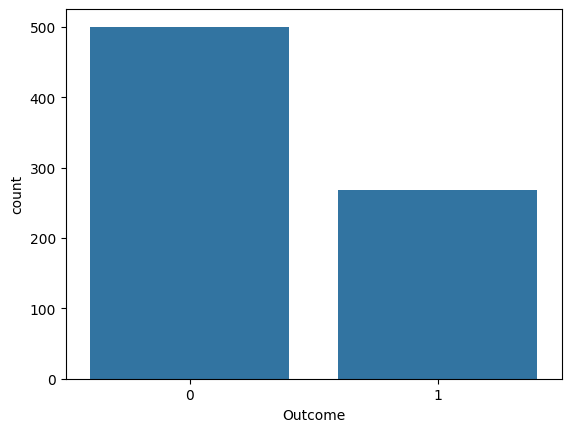

In [6]:
sns.countplot(x='Outcome', data=df_pima)

<Axes: xlabel='income', ylabel='count'>

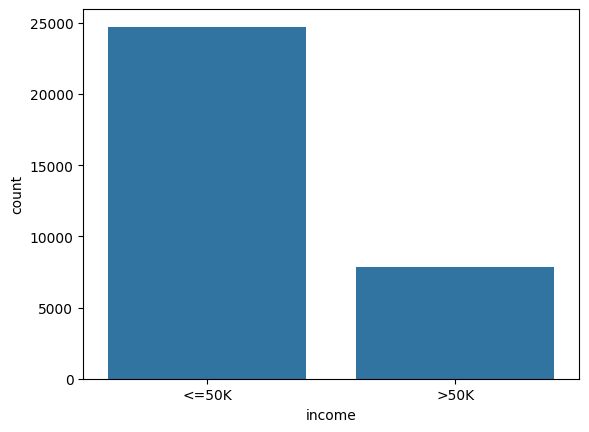

In [7]:
sns.countplot(x='income', data=df_adult)

Виден дисбаланс классов - использую F1, а не ACC

Поменял порядок пунктов плана ДЗ: всё-таки сделаю scaler до заполнения медианой ради сохранения исходного распределения признаков

In [3]:
pima_missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in pima_missing_cols:
    df_pima[col] = df_pima[col].replace(0, np.nan)

X_pima = df_pima.drop('Outcome', axis=1)
y_pima = df_pima['Outcome']

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima, y_pima, test_size=0.2, random_state=42, stratify=y_pima
)

train_medians = X_train_pima[pima_missing_cols].median()

X_train_pima[pima_missing_cols] = X_train_pima[pima_missing_cols].fillna(train_medians)
X_test_pima[pima_missing_cols] = X_test_pima[pima_missing_cols].fillna(train_medians)

scaler_pima = StandardScaler()
scaler_pima.fit(X_train_pima)

X_train_pima_scaled = scaler_pima.transform(X_train_pima)
X_test_pima_scaled = scaler_pima.transform(X_test_pima)

print(np.isnan(X_train_pima_scaled).sum(), np.isnan(X_test_pima_scaled).sum())

0 0


In [4]:
df_adult['income'] = df_adult['income'].astype(str).str.strip()
df_adult['income'] = df_adult['income'].map({'<=50K': 0, '>50K': 1})

adult_categorical_missing_cols = ['workclass', 'occupation', 'native_country']

X_adult = df_adult.drop('income', axis=1)
y_adult = df_adult['income']

X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(
    X_adult, y_adult, test_size=0.2, random_state=42, stratify=y_adult
)

train_modes = X_train_adult[adult_categorical_missing_cols].mode().iloc[0]

X_train_adult[adult_categorical_missing_cols] = X_train_adult[adult_categorical_missing_cols].fillna(train_modes)
X_test_adult[adult_categorical_missing_cols] = X_test_adult[adult_categorical_missing_cols].fillna(train_modes)

categorical_features = X_train_adult.select_dtypes(include=['object']).columns

X_train_adult = pd.get_dummies(X_train_adult, columns=categorical_features, drop_first=True)
X_test_adult = pd.get_dummies(X_test_adult, columns=categorical_features, drop_first=True)

X_train_adult, X_test_adult = X_train_adult.align(X_test_adult, join='left', axis=1, fill_value=0)

scaler_adult = StandardScaler()
scaler_adult.fit(X_train_adult)

X_train_adult_scaled = scaler_adult.transform(X_train_adult)
X_test_adult_scaled = scaler_adult.transform(X_test_adult)

print(np.isnan(X_train_adult_scaled).sum(), np.isnan(X_test_adult_scaled).sum())

0 0


In [5]:
models_pima = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'KNeighborsClassifier': KNeighborsClassifier()
}
models_adult = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42),
    'RandomForestClassifier': RandomForestClassifier(random_state=42),
    'GradientBoostingClassifier': GradientBoostingClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'KNeighborsClassifier': KNeighborsClassifier()
}

pima_trained_models = {}
pima_predictions = {}

print("--- Training models for Pima Indians Diabetes Dataset ---")
for name, model in models_pima.items():
    print(f"Training {name}...")
    model.fit(X_train_pima_scaled, y_train_pima)
    pima_trained_models[name] = model
    pima_predictions[name] = model.predict(X_test_pima_scaled)

adult_trained_models = {}
adult_predictions = {}

print("\n--- Training models for Adult Income Dataset ---")
for name, model in models_adult.items():
    print(f"Training {name}...")
    model.fit(X_train_adult_scaled, y_train_adult)
    adult_trained_models[name] = model
    adult_predictions[name] = model.predict(X_test_adult_scaled)

--- Training models for Pima Indians Diabetes Dataset ---
Training LogisticRegression...
Training SVM...
Training RandomForestClassifier...
Training GradientBoostingClassifier...
Training GaussianNB...
Training KNeighborsClassifier...

--- Training models for Adult Income Dataset ---
Training LogisticRegression...
Training SVM...
Training RandomForestClassifier...
Training GradientBoostingClassifier...
Training GaussianNB...
Training KNeighborsClassifier...


In [6]:
print("--- Classification Reports for Pima Indians Diabetes Dataset ---")
for name, predictions in pima_predictions.items():
    print(f"\n{name}:")
    print(classification_report(y_test_pima, predictions))

print("\n--- Classification Reports for Adult Income Dataset ---")
for name, predictions in adult_predictions.items():
    print(f"\n{name}:")
    print(classification_report(y_test_adult, predictions))

--- Classification Reports for Pima Indians Diabetes Dataset ---

LogisticRegression:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


SVM:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154


RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.61      0.65        54

    accuracy                           0.77       154
   macro av

Гаусс выбывает из гонки нормальных решений, остальные плюс-минус одинаково держаться. Самыми вкусными оказались randomforest и бустинг (сделайте удивленные лица) - выдают высокие показатели на основном классе и не сильно унижают малочисленный.

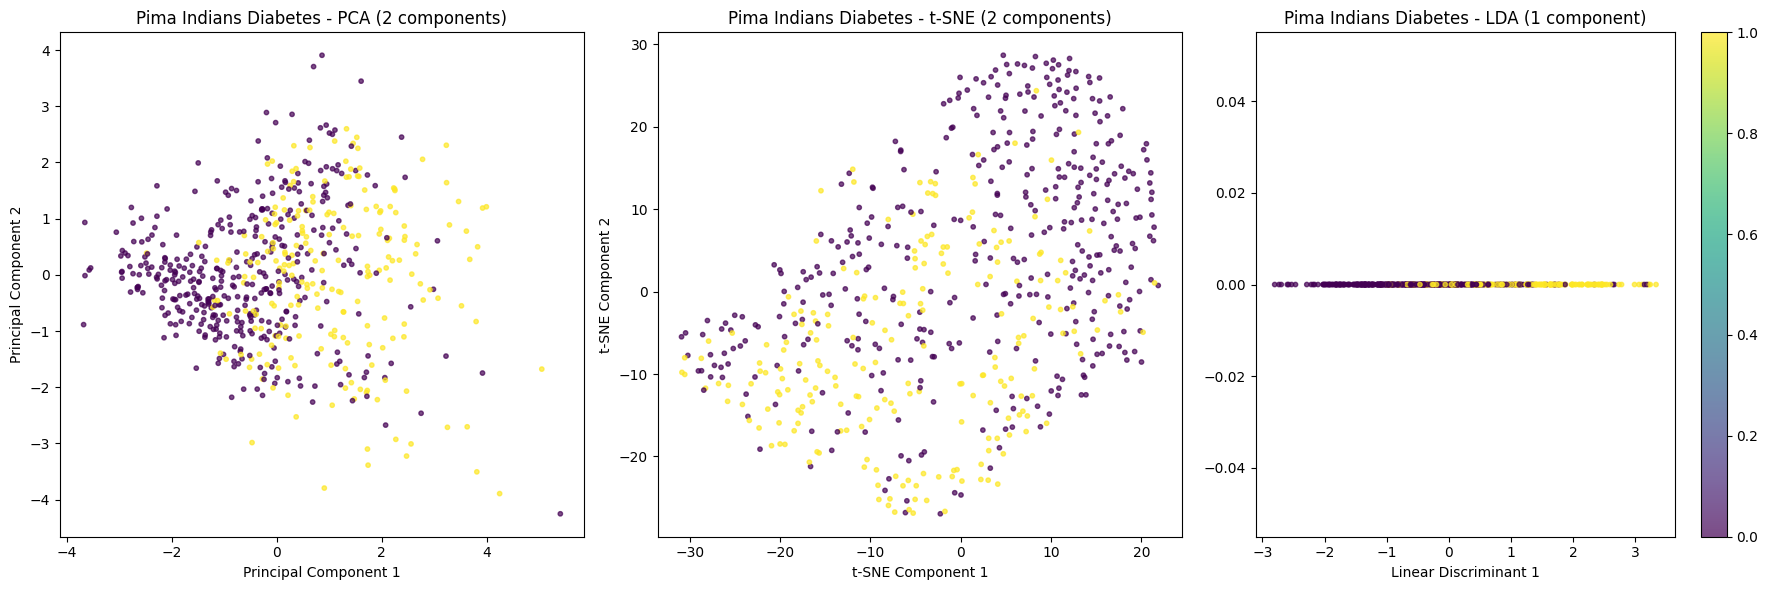

In [12]:
pca_pima = PCA(n_components=2, random_state=42)
X_train_pima_pca = pca_pima.fit_transform(X_train_pima_scaled)

tsne_pima = TSNE(n_components=2, random_state=42, init='random', learning_rate='auto')
X_train_pima_tsne = tsne_pima.fit_transform(X_train_pima_scaled)

lda_pima = LDA(n_components=1)
X_train_pima_lda = lda_pima.fit_transform(X_train_pima_scaled, y_train_pima)

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.scatter(X_train_pima_pca[:, 0], X_train_pima_pca[:, 1], c=y_train_pima, cmap='viridis', s=10, alpha=0.7)
plt.title('Pima Indians Diabetes - PCA (2 components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.subplot(1, 3, 2)
plt.scatter(X_train_pima_tsne[:, 0], X_train_pima_tsne[:, 1], c=y_train_pima, cmap='viridis', s=10, alpha=0.7)
plt.title('Pima Indians Diabetes - t-SNE (2 components)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.subplot(1, 3, 3)
plt.scatter(X_train_pima_lda[:, 0], np.zeros_like(X_train_pima_lda[:, 0]), c=y_train_pima, cmap='viridis', s=10, alpha=0.7)
plt.title('Pima Indians Diabetes - LDA (1 component)')
plt.xlabel('Linear Discriminant 1')
plt.colorbar()
plt.tight_layout()
plt.show()

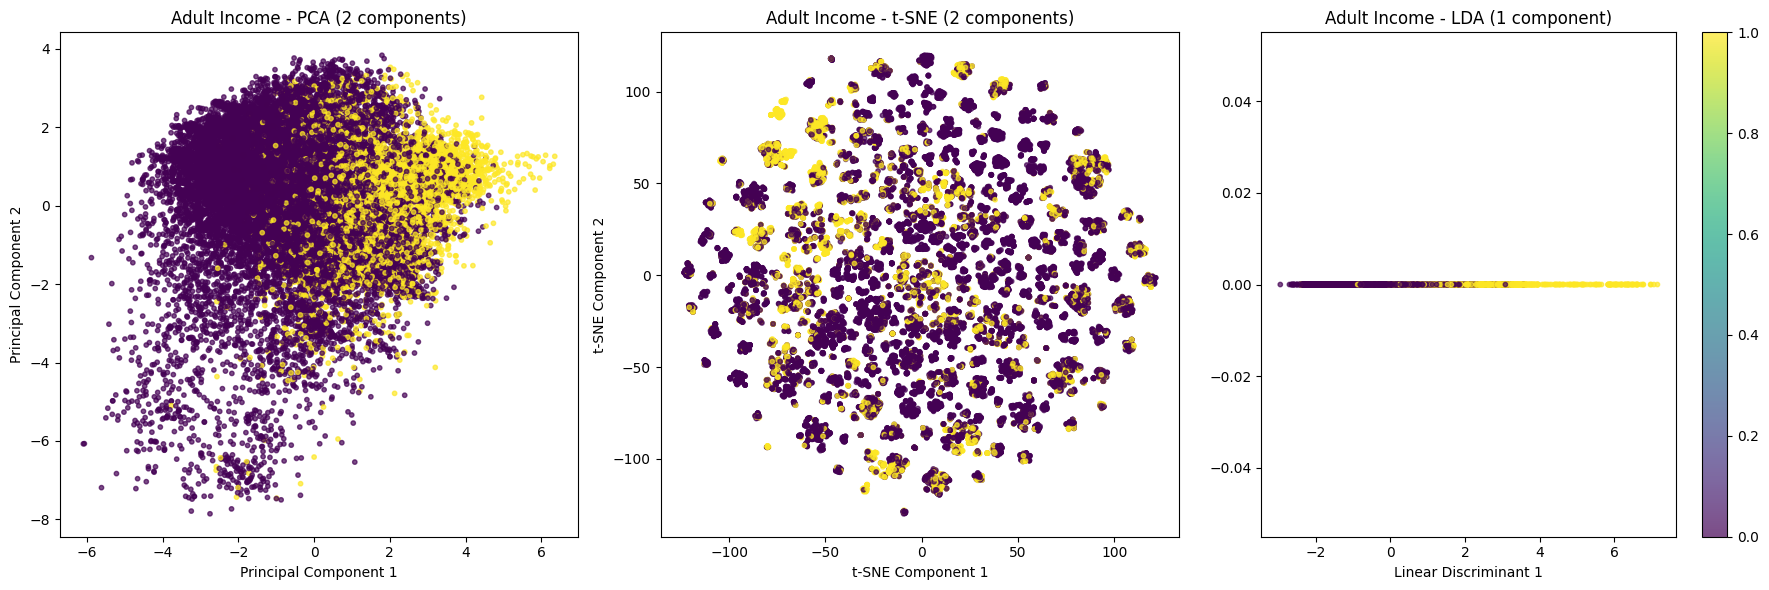

In [13]:
pca_adult = PCA(n_components=2, random_state=42)
X_train_adult_pca = pca_adult.fit_transform(X_train_adult_scaled)

tsne_adult = TSNE(n_components=2, random_state=42, init='random', learning_rate='auto')
X_train_adult_tsne = tsne_adult.fit_transform(X_train_adult_scaled)

lda_adult = LDA(n_components=1)
X_train_adult_lda = lda_adult.fit_transform(X_train_adult_scaled, y_train_adult)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(X_train_adult_pca[:, 0], X_train_adult_pca[:, 1], c=y_train_adult, cmap='viridis', s=10, alpha=0.7)
plt.title('Adult Income - PCA (2 components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.subplot(1, 3, 2)
plt.scatter(X_train_adult_tsne[:, 0], X_train_adult_tsne[:, 1], c=y_train_adult, cmap='viridis', s=10, alpha=0.7)
plt.title('Adult Income - t-SNE (2 components)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.subplot(1, 3, 3)
plt.scatter(X_train_adult_lda[:, 0], np.zeros_like(X_train_adult_lda[:, 0]), c=y_train_adult, cmap='viridis', s=10, alpha=0.7)
plt.title('Adult Income - LDA (1 component)')
plt.xlabel('Linear Discriminant 1')
plt.colorbar()
plt.tight_layout()
plt.show()


Судя по графикам для обоих датасетов и полученными ранее метриками, решать задачу классическими ML методами есть

Использую F1 из-за дисбаланса класса.

In [14]:
bootstrap_iterations = [10, 25, 50]
adult_bootstrap_results = {}

for name, model in adult_trained_models.items():
    print(f"\n{name}")
    for iter in bootstrap_iterations:
      scores = []

      for _ in range(iter):
          X_resample, y_resample = resample(X_train_adult_scaled, y_train_adult, random_state=_)
          model.fit(X_resample, y_resample)
          y_pred = model.predict(X_test_adult_scaled)
          acc = f1_score(y_test_adult, y_pred, average='macro')
          scores.append(acc)

      scores = np.array(scores)
      mean_acc = np.mean(scores)
      variance = np.var(scores)
      std = np.std(scores)

      adult_bootstrap_results.setdefault(name, {})[iter] = {
          "mean_f1": mean_acc,
          "variance": variance,
          "std": std
      }

      print(f"{iter}, Mean F1: {mean_acc:.4f}, Variance: {variance:.6f}, Std: {std:.6f}")


LogisticRegression
10, Mean F1: 0.7874, Variance: 0.000003, Std: 0.001809
25, Mean F1: 0.7877, Variance: 0.000002, Std: 0.001524
50, Mean F1: 0.7877, Variance: 0.000003, Std: 0.001677

SVM
10, Mean F1: 0.7762, Variance: 0.000019, Std: 0.004371
25, Mean F1: 0.7772, Variance: 0.000014, Std: 0.003778
50, Mean F1: 0.7772, Variance: 0.000011, Std: 0.003373

RandomForestClassifier
10, Mean F1: 0.7921, Variance: 0.000006, Std: 0.002367
25, Mean F1: 0.7910, Variance: 0.000007, Std: 0.002706
50, Mean F1: 0.7909, Variance: 0.000008, Std: 0.002863

GradientBoostingClassifier
10, Mean F1: 0.8057, Variance: 0.000005, Std: 0.002137
25, Mean F1: 0.8060, Variance: 0.000003, Std: 0.001837
50, Mean F1: 0.8058, Variance: 0.000004, Std: 0.002106

GaussianNB
10, Mean F1: 0.3662, Variance: 0.003043, Std: 0.055162
25, Mean F1: 0.3735, Variance: 0.002494, Std: 0.049937
50, Mean F1: 0.3689, Variance: 0.002184, Std: 0.046739

KNeighborsClassifier
10, Mean F1: 0.7322, Variance: 0.000021, Std: 0.004557
25, Mean 

In [15]:
bootstrap_iterations = [100, 250, 500]
pima_bootstrap_results = {}

for name, model in pima_trained_models.items():
    print(f"\n{name}")
    for iter in bootstrap_iterations:
      scores = []

      for _ in range(iter):
          X_resample, y_resample = resample(X_train_pima_scaled, y_train_pima, random_state=_)
          model.fit(X_resample, y_resample)
          y_pred = model.predict(X_test_pima_scaled)
          acc = f1_score(y_test_pima, y_pred, average='macro')
          scores.append(acc)

      scores = np.array(scores)
      mean_acc = np.mean(scores)
      variance = np.var(scores)
      std = np.std(scores)

      pima_bootstrap_results.setdefault(name, {})[iter] = {
          "mean_f1": mean_acc,
          "variance": variance,
          "std": std
      }

      print(f"{iter}, Mean F1: {mean_acc:.4f}, Variance: {variance:.6f}, Std: {std:.6f}")


LogisticRegression
100, Mean F1: 0.6730, Variance: 0.000218, Std: 0.014772
250, Mean F1: 0.6734, Variance: 0.000228, Std: 0.015112
500, Mean F1: 0.6737, Variance: 0.000217, Std: 0.014737

SVM
100, Mean F1: 0.6890, Variance: 0.000463, Std: 0.021512
250, Mean F1: 0.6883, Variance: 0.000454, Std: 0.021318
500, Mean F1: 0.6880, Variance: 0.000437, Std: 0.020901

RandomForestClassifier
100, Mean F1: 0.7009, Variance: 0.000470, Std: 0.021687
250, Mean F1: 0.7003, Variance: 0.000462, Std: 0.021483
500, Mean F1: 0.6995, Variance: 0.000475, Std: 0.021784

GradientBoostingClassifier
100, Mean F1: 0.7071, Variance: 0.000547, Std: 0.023397
250, Mean F1: 0.7077, Variance: 0.000601, Std: 0.024518
500, Mean F1: 0.7064, Variance: 0.000597, Std: 0.024442

GaussianNB
100, Mean F1: 0.6742, Variance: 0.000099, Std: 0.009964
250, Mean F1: 0.6751, Variance: 0.000097, Std: 0.009867
500, Mean F1: 0.6754, Variance: 0.000105, Std: 0.010237

KNeighborsClassifier
100, Mean F1: 0.6833, Variance: 0.000736, Std: 0.

Модели устойчивы на данных и смысл хранить несколько экземпляров отпадает

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

param_dist_adult = {
    'C': loguniform(0.1, 100),
    'gamma': loguniform(0.001, 1),
    'kernel': ['rbf', 'linear']
}

svm_adult = SVC(random_state=42)

random_search_adult = RandomizedSearchCV(svm_adult, param_distributions=param_dist_adult, n_iter=10, cv=5, scoring='f1', random_state=42, n_jobs=-1, verbose=1)
random_search_adult.fit(X_train_adult_scaled, y_train_adult)

print("\n--- RandomizedSearchCV Results for Adult Income (SVM) ---")
print(f"Best Parameters: {random_search_adult.best_params_}")
print(f"Best Cross-Validation Score: {random_search_adult.best_score_:.4f}")

best_svm_adult = random_search_adult.best_estimator_
y_pred_best_svm_adult = best_svm_adult.predict(X_test_adult_scaled)

print("\nClassification Report for Best SVM (Adult Income) on Test Set:")
print(classification_report(y_test_adult, y_pred_best_svm_adult))


In [8]:
param_dist_pima = {
    'C': loguniform(0.1, 100),
    'gamma': loguniform(0.001, 1),
    'kernel': ['rbf', 'linear']
}

svm_pima = SVC(random_state=42)
random_search_pima = RandomizedSearchCV(svm_pima, param_distributions=param_dist_pima, n_iter=10, cv=5, scoring='f1', random_state=42, n_jobs=-1, verbose=1)
random_search_pima.fit(X_train_pima_scaled, y_train_pima)

print("\n--- RandomizedSearchCV Results for Pima Indians Diabetes (SVM) ---")
print(f"Best Parameters: {random_search_pima.best_params_}")
print(f"Best Cross-Validation Score: {random_search_pima.best_score_:.4f}")

best_svm_pima = random_search_pima.best_estimator_
y_pred_best_svm_pima = best_svm_pima.predict(X_test_pima_scaled)

print("\nClassification Report for Best SVM (Pima Indians Diabetes) on Test Set:")
print(classification_report(y_test_pima, y_pred_best_svm_pima))


Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- RandomizedSearchCV Results for Pima Indians Diabetes (SVM) ---
Best Parameters: {'C': np.float64(0.2937538457632829), 'gamma': np.float64(0.0014936568554617625), 'kernel': 'linear'}
Best Cross-Validation Score: 0.6286

Classification Report for Best SVM (Pima Indians Diabetes) on Test Set:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       100
           1       0.60      0.48      0.54        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.66       154
weighted avg       0.70      0.71      0.70       154



**Выводы**
1. SVM показал хороший результат из перечисленных в работе относительно F1 меры.
2. Все модели оказались стабильны на представленных датасетах. Монте-Карло оказался излишним для итоговой имплементации моделей в этих задачах.
3. Понижение размерности показало, что разбиение классов +- возможно способами классического мл.
4. Показатели SVM: F1: 0.7772, Std: 0.003373.

Лучшие параметры: 'C': np.float64(0.2937538457632829), 'gamma': np.float64(0.0014936568554617625), 'kernel': 'linear'